## Baseline, Logistic Regression & Decision Tree

This notebook trains and evaluates three models using the preprocessed parquets from `artifacts/`. We run each model on both feature sets (with and without `IS_COVID`) to see if the COVID flag makes a difference.

1. Load the preprocessed data
2. Route-lookup baseline (non-ML sanity check)
3. Logistic Regression (linear baseline)
4. Decision Tree (first non-linear model)
5. Compare everything


In [ ]:
import os, gc, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100

RAW_DATA_PATH = 'flights_with_weather.csv'
ART_DIR       = r'C:\Users\saeli\OneDrive\artifacts'
MODEL_DIR     = 'model_weights'
os.makedirs(MODEL_DIR, exist_ok=True)

---
## 1. Load the preprocessed data

Everything lives in `artifacts/`. There are two versions of the feature matrices — one with `IS_COVID` (25 features) and one without (24 features). The targets are shared.

Temporal split: Train (before Jul 2022), Val (Jul–Dec 2022), Test (2023).

In [10]:
# Load both feature versions from the single artifacts/ folder
X_tr_cov = pd.read_parquet(f'{ART_DIR}/X_train_with_covid.parquet')
X_v_cov  = pd.read_parquet(f'{ART_DIR}/X_val_with_covid.parquet')
X_te_cov = pd.read_parquet(f'{ART_DIR}/X_test_with_covid.parquet')

X_tr_nc  = pd.read_parquet(f'{ART_DIR}/X_train_no_covid.parquet')
X_v_nc   = pd.read_parquet(f'{ART_DIR}/X_val_no_covid.parquet')
X_te_nc  = pd.read_parquet(f'{ART_DIR}/X_test_no_covid.parquet')

y_train = pd.read_parquet(f'{ART_DIR}/y_train.parquet')['CANCELLED'].values
y_val   = pd.read_parquet(f'{ART_DIR}/y_val.parquet')['CANCELLED'].values
y_test  = pd.read_parquet(f'{ART_DIR}/y_test.parquet')['CANCELLED'].values

for name, n in [('Train', len(y_train)), ('Val', len(y_val)), ('Test', len(y_test))]:
    y = {'Train': y_train, 'Val': y_val, 'Test': y_test}[name]
    print(f'{name:5s}: {n:>10,} rows  |  cancel rate: {y.mean():.2%}')

print(f'\nWith COVID:    {X_tr_cov.shape[1]} features')
print(f'Without COVID: {X_tr_nc.shape[1]} features')

Train:  2,186,803 rows  |  cancel rate: 2.92%
Val  :    349,591 rows  |  cancel rate: 2.16%
Test :    698,587 rows  |  cancel rate: 2.06%

With COVID:    25 features
Without COVID: 24 features


In [11]:
# Shared evaluation function used by all models in this notebook
results    = {'with_covid': [], 'no_covid': []}
pr_curves  = {}
roc_curves = {}

def evaluate_model(name, y_true, y_pred, y_pred_proba, version='with_covid'):
    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'F2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_pred_proba),
        'PR-AUC':    average_precision_score(y_true, y_pred_proba),
    }
    results[version].append(metrics)

    key = f'{name} [{version}]'
    prec, rec, _ = precision_recall_curve(y_true, y_pred_proba)
    fpr,  tpr, _ = roc_curve(y_true, y_pred_proba)
    pr_curves[key]  = (prec, rec)
    roc_curves[key] = (fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=axes[0],
        display_labels=['Operated', 'Cancelled'],
        colorbar=False, cmap='Blues')
    axes[0].set_title(f'{name} [{version}]')
    axes[1].plot(rec, prec, color='steelblue', linewidth=2)
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve (AUC = {metrics["PR-AUC"]:.4f})')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print(f'\n{name} [{version}]')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:10s}: {v:.4f}')
    return metrics

---
## 2. Statistical baseline based on flight routes

For each flight, we just look up the historical cancellation rate for that ORIGIN→DEST route from the training period. If we haven't seen the route before, we fall back to the global average. Simple dictionary lookup, no ML involved.

This is the floor — any real model should beat this. We need the raw airport codes for the lookup, so we reload a few columns from the original CSV.

Routes in lookup: 7,608  |  Global fallback rate: 0.0292
Optimal threshold (val F1=0.0589): 0.040


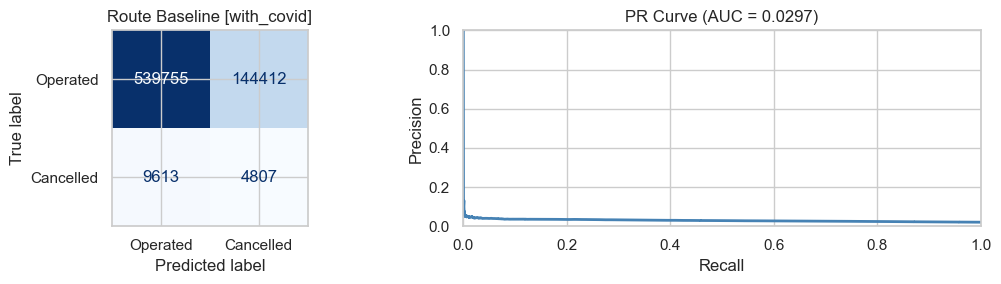


Route Baseline [with_covid]
  Accuracy  : 0.7795
  Precision : 0.0322
  Recall    : 0.3334
  F1        : 0.0588
  F2        : 0.1162
  ROC-AUC   : 0.6010
  PR-AUC    : 0.0297


In [12]:
df_bl = pd.read_csv(
    RAW_DATA_PATH,
    usecols=['FL_DATE', 'ORIGIN', 'DEST', 'CANCELLED'],
    dtype={'ORIGIN': str, 'DEST': str, 'CANCELLED': 'int8'},
    parse_dates=['FL_DATE']
)

train_mask_bl = df_bl['FL_DATE'] <  '2022-07-01'
val_mask_bl   = (df_bl['FL_DATE'] >= '2022-07-01') & (df_bl['FL_DATE'] < '2023-01-01')
test_mask_bl  = df_bl['FL_DATE'] >= '2023-01-01'

route_rates = (
    df_bl.loc[train_mask_bl, ['ORIGIN', 'DEST', 'CANCELLED']]
    .groupby(['ORIGIN', 'DEST'])['CANCELLED']
    .mean()
    .to_dict()
)
route_rates = {k: v for k, v in route_rates.items() if not np.isnan(v)}

global_rate = float(df_bl.loc[train_mask_bl, 'CANCELLED'].mean())
print(f'Routes in lookup: {len(route_rates):,}  |  Global fallback rate: {global_rate:.4f}')

def baseline_predict(origins, dests):
    return np.array([
        route_rates.get((o, d), global_rate)
        for o, d in zip(origins, dests)
    ])

# Tune decision threshold on val set to maximise F1
val_proba_bl = baseline_predict(
    df_bl.loc[val_mask_bl, 'ORIGIN'].values,
    df_bl.loc[val_mask_bl, 'DEST'].values
)
y_val_bl = df_bl.loc[val_mask_bl, 'CANCELLED'].values

best_f1, best_thresh = 0.0, 0.05
for thresh in np.arange(0.01, 0.21, 0.005):
    preds = (val_proba_bl >= thresh).astype(int)
    score = f1_score(y_val_bl, preds, zero_division=0)
    if score > best_f1:
        best_f1, best_thresh = score, thresh
print(f'Optimal threshold (val F1={best_f1:.4f}): {best_thresh:.3f}')

# Generate test-set predictions
test_proba_bl = baseline_predict(
    df_bl.loc[test_mask_bl, 'ORIGIN'].values,
    df_bl.loc[test_mask_bl, 'DEST'].values
)
test_preds_bl = (test_proba_bl >= best_thresh).astype(int)

del df_bl
gc.collect()

# Evaluate once — baseline doesn't use any preprocessed features, so COVID flag is irrelevant.
# We add the same result to both version lists so it shows up in both comparison tables.
bl_metrics = evaluate_model('Route Baseline', y_test, test_preds_bl, test_proba_bl, version='with_covid')
results['no_covid'].append(bl_metrics)

---
## 3. Logistic Regression

Our interpretable linear baseline. We try a few regularisation strengths (C values) and pick the one with the best validation PR-AUC, then report final numbers on the test set.

Key choices:
- `class_weight='balanced'` to handle the imbalance
- `solver='saga'` since it's efficient on 2M+ rows
- We also tune the decision threshold on validation to maximise F2 (recall-weighted)


--- Logistic Regression [with_covid] (25 features) ---
  C=0.01   val PR-AUC: 0.0768
  C=0.1    val PR-AUC: 0.0768
  C=1.0    val PR-AUC: 0.0768
  C=10.0   val PR-AUC: 0.0768
  Best C: 0.01 (val PR-AUC = 0.0768)
  Best threshold: 0.34 (val F2 = 0.1875)


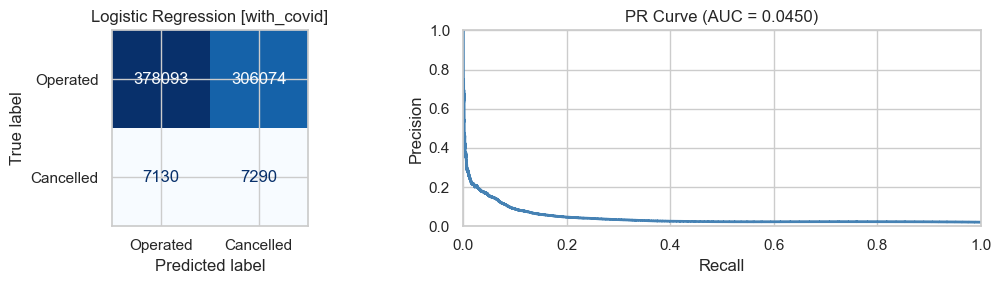


Logistic Regression [with_covid]
  Accuracy  : 0.5517
  Precision : 0.0233
  Recall    : 0.5055
  F1        : 0.0445
  F2        : 0.0982
  ROC-AUC   : 0.5796
  PR-AUC    : 0.0450
  Saved: model_weights/logistic_regression_with_covid.pkl

--- Logistic Regression [no_covid] (24 features) ---
  C=0.01   val PR-AUC: 0.0730
  C=0.1    val PR-AUC: 0.0730
  C=1.0    val PR-AUC: 0.0730
  C=10.0   val PR-AUC: 0.0730
  Best C: 0.01 (val PR-AUC = 0.0730)
  Best threshold: 0.39 (val F2 = 0.1806)


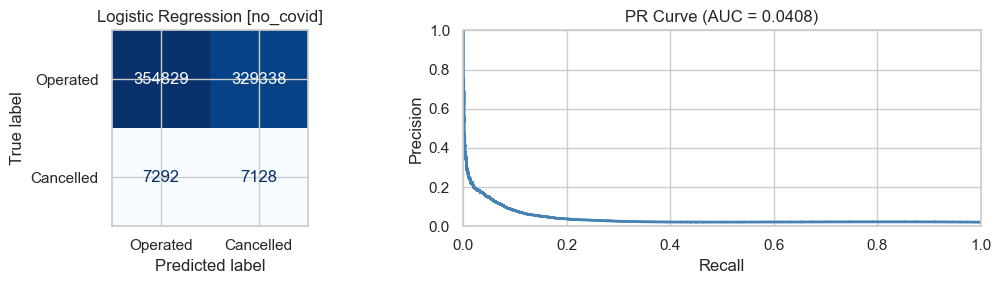


Logistic Regression [no_covid]
  Accuracy  : 0.5181
  Precision : 0.0212
  Recall    : 0.4943
  F1        : 0.0406
  F2        : 0.0904
  ROC-AUC   : 0.5500
  PR-AUC    : 0.0408
  Saved: model_weights/logistic_regression_no_covid.pkl


In [13]:
for version, X_tr, X_v, X_te in [
    ('with_covid', X_tr_cov, X_v_cov, X_te_cov),
    ('no_covid',   X_tr_nc,  X_v_nc,  X_te_nc),
]:
    print(f'\n--- Logistic Regression [{version}] ({X_tr.shape[1]} features) ---')

    # Try a few C values on validation to pick the best regularisation
    best_lr, best_prauc, best_c = None, -1, None
    for c_val in [0.01, 0.1, 1.0, 10.0]:
        lr = LogisticRegression(
            class_weight='balanced', C=c_val, solver='saga',
            max_iter=1000, n_jobs=-1, random_state=42)
        lr.fit(X_tr, y_train)
        val_proba = lr.predict_proba(X_v)[:, 1]
        prauc = average_precision_score(y_val, val_proba)
        print(f'  C={c_val:<5}  val PR-AUC: {prauc:.4f}')
        if prauc > best_prauc:
            best_prauc, best_lr, best_c = prauc, lr, c_val

    print(f'  Best C: {best_c} (val PR-AUC = {best_prauc:.4f})')

    # Tune threshold on validation to maximise F2
    val_proba = best_lr.predict_proba(X_v)[:, 1]
    best_t, best_f2 = 0.5, 0.0
    for t in np.linspace(0, 1, 101):
        f2 = fbeta_score(y_val, (val_proba >= t).astype(int), beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    print(f'  Best threshold: {best_t:.2f} (val F2 = {best_f2:.4f})')

    # Final evaluation on test
    test_proba = best_lr.predict_proba(X_te)[:, 1]
    test_pred  = (test_proba >= best_t).astype(int)
    evaluate_model('Logistic Regression', y_test, test_pred, test_proba, version=version)

    out_path = f'{MODEL_DIR}/logistic_regression_{version}.pkl'
    joblib.dump(best_lr, out_path)
    print(f'  Saved: {out_path}')

---
## 4. Decision Tree

First non-linear model — can pick up conditional patterns like "February + ORD + regional carrier = high cancel risk" that LR can't capture.

We try a few `max_depth` values on validation and use constraints (`min_samples_split`, `min_samples_leaf`) to avoid overfitting the 2M+ training rows. Threshold is tuned on validation for F2, same as LR.


--- Decision Tree [with_covid] (25 features) ---
  max_depth=5    val PR-AUC: 0.0485
  max_depth=8    val PR-AUC: 0.0669
  max_depth=10   val PR-AUC: 0.0866
  max_depth=15   val PR-AUC: 0.0866
  max_depth=20   val PR-AUC: 0.0853
  Best depth: 10 (val PR-AUC = 0.0866)
  Best threshold: 0.47 (val F2 = 0.1822)


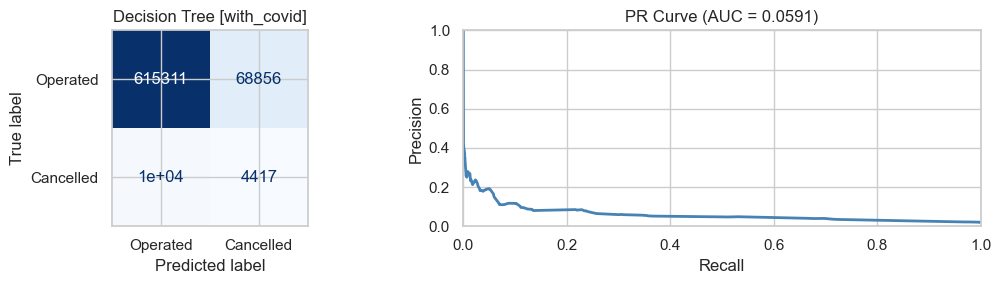


Decision Tree [with_covid]
  Accuracy  : 0.8871
  Precision : 0.0603
  Recall    : 0.3063
  F1        : 0.1007
  F2        : 0.1686
  ROC-AUC   : 0.7002
  PR-AUC    : 0.0591
  Saved: model_weights/decision_tree_with_covid.pkl

--- Decision Tree [no_covid] (24 features) ---
  max_depth=5    val PR-AUC: 0.0485
  max_depth=8    val PR-AUC: 0.0694
  max_depth=10   val PR-AUC: 0.0874
  max_depth=15   val PR-AUC: 0.0838
  max_depth=20   val PR-AUC: 0.0824
  Best depth: 10 (val PR-AUC = 0.0874)
  Best threshold: 0.41 (val F2 = 0.1908)


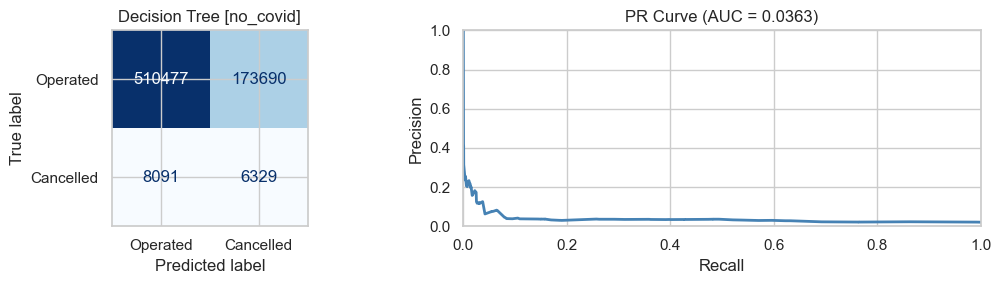


Decision Tree [no_covid]
  Accuracy  : 0.7398
  Precision : 0.0352
  Recall    : 0.4389
  F1        : 0.0651
  F2        : 0.1331
  ROC-AUC   : 0.5997
  PR-AUC    : 0.0363
  Saved: model_weights/decision_tree_no_covid.pkl


In [14]:
for version, X_tr, X_v, X_te in [
    ('with_covid', X_tr_cov, X_v_cov, X_te_cov),
    ('no_covid',   X_tr_nc,  X_v_nc,  X_te_nc),
]:
    print(f'\n--- Decision Tree [{version}] ({X_tr.shape[1]} features) ---')

    # Try different tree depths on validation
    best_dt, best_prauc, best_depth = None, -1, None
    for depth in [5, 8, 10, 15, 20]:
        dt = DecisionTreeClassifier(
            class_weight='balanced', max_depth=depth,
            min_samples_split=500, min_samples_leaf=200, random_state=42)
        dt.fit(X_tr, y_train)
        val_proba = dt.predict_proba(X_v)[:, 1]
        prauc = average_precision_score(y_val, val_proba)
        print(f'  max_depth={depth:<3}  val PR-AUC: {prauc:.4f}')
        if prauc > best_prauc:
            best_prauc, best_dt, best_depth = prauc, dt, depth

    print(f'  Best depth: {best_depth} (val PR-AUC = {best_prauc:.4f})')

    # Tune threshold on validation for F2
    val_proba = best_dt.predict_proba(X_v)[:, 1]
    best_t, best_f2 = 0.5, 0.0
    for t in np.linspace(0, 1, 101):
        f2 = fbeta_score(y_val, (val_proba >= t).astype(int), beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    print(f'  Best threshold: {best_t:.2f} (val F2 = {best_f2:.4f})')

    # Final evaluation on test
    test_proba = best_dt.predict_proba(X_te)[:, 1]
    test_pred  = (test_proba >= best_t).astype(int)
    evaluate_model('Decision Tree', y_test, test_pred, test_proba, version=version)

    out_path = f'{MODEL_DIR}/decision_tree_{version}.pkl'
    joblib.dump(best_dt, out_path)
    print(f'  Saved: {out_path}')

---
## 5. Compare everything

Let's see how the models stack up against each other — and whether the COVID flag actually helped.


=== Model Comparison [with_covid] — sorted by PR-AUC ===
                     Accuracy  Precision  Recall      F1      F2  ROC-AUC  PR-AUC
Model                                                                            
Decision Tree          0.8871     0.0603  0.3063  0.1007  0.1686   0.7002  0.0591
Logistic Regression    0.5517     0.0233  0.5055  0.0445  0.0982   0.5796  0.0450
Route Baseline         0.7795     0.0322  0.3334  0.0588  0.1162   0.6010  0.0297


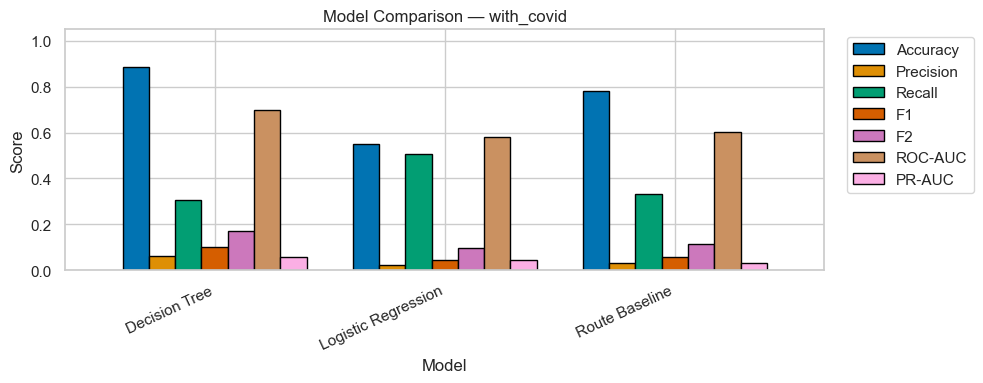


=== Model Comparison [no_covid] — sorted by PR-AUC ===
                     Accuracy  Precision  Recall      F1      F2  ROC-AUC  PR-AUC
Model                                                                            
Logistic Regression    0.5181     0.0212  0.4943  0.0406  0.0904   0.5500  0.0408
Decision Tree          0.7398     0.0352  0.4389  0.0651  0.1331   0.5997  0.0363
Route Baseline         0.7795     0.0322  0.3334  0.0588  0.1162   0.6010  0.0297


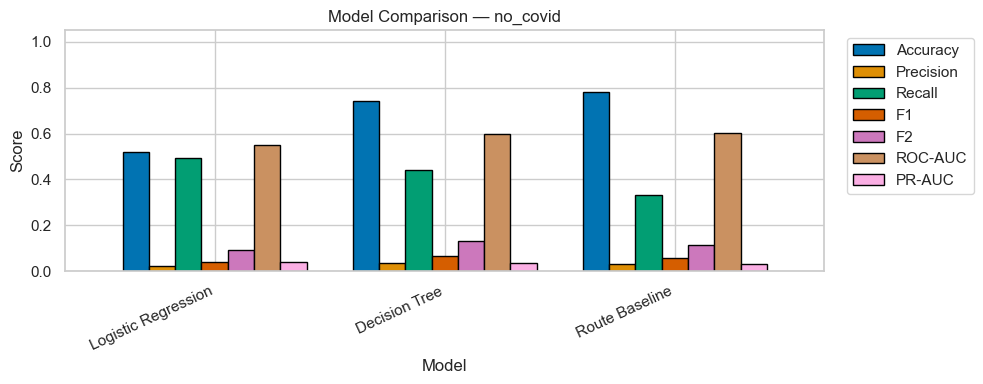

In [15]:
for version in ['with_covid', 'no_covid']:
    if not results[version]:
        continue
    df_res = pd.DataFrame(results[version]).sort_values('PR-AUC', ascending=False)
    print(f'\n=== Model Comparison [{version}] — sorted by PR-AUC ===')
    print(df_res.set_index('Model').round(4).to_string())

    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'ROC-AUC', 'PR-AUC']
    fig, ax = plt.subplots(figsize=(max(10, len(df_res) * 3), 4))
    df_res.set_index('Model')[metric_cols].plot.bar(ax=ax, edgecolor='black', width=0.8)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Model Comparison — {version}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

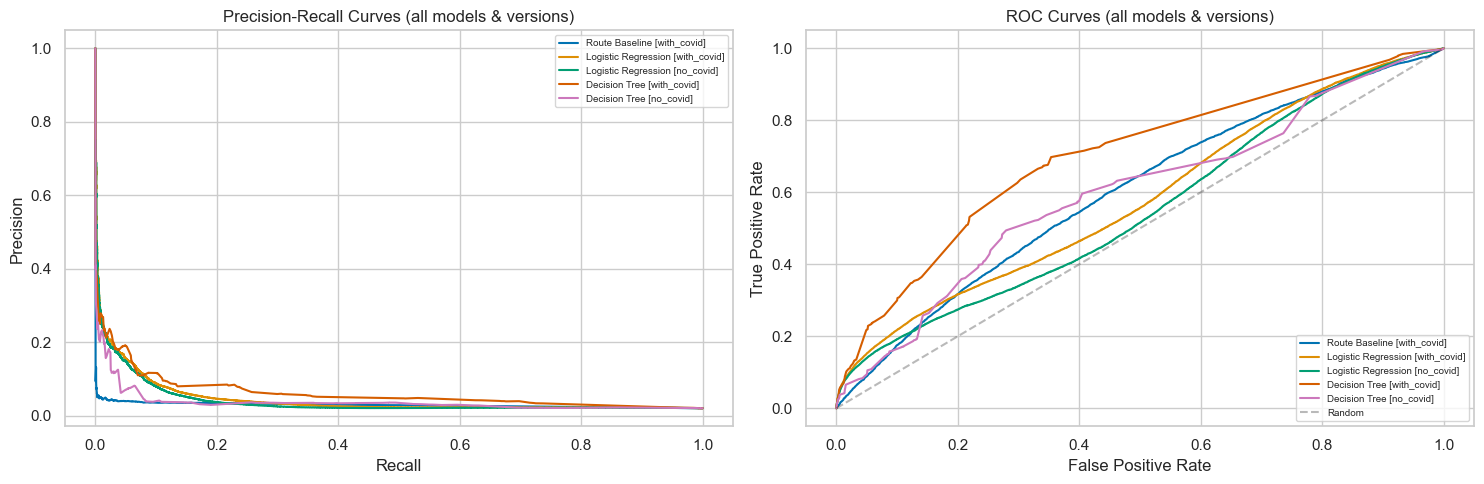

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for key, (prec, rec) in pr_curves.items():
    axes[0].plot(rec, prec, linewidth=1.5, label=key)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves (all models & versions)')
axes[0].legend(fontsize=7, loc='upper right')

for key, (fpr, tpr) in roc_curves.items():
    axes[1].plot(fpr, tpr, linewidth=1.5, label=key)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (all models & versions)')
axes[1].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

---
## 6. Summary & Conclusions

This evaluated three models; a statistical route-based baseline, Logistic Regression, and Decision Tree, which across two feature sets (with and without the COVID flag).

**Statistical Baseline** sets the performance floor using only historical route-level cancellation rates. It requires no training and no features beyond, yet still achieves a non-trivial PR-AUC by capturing persistent geographic risk patterns. If any ML model that cannot beat this, it does not justify its added complexity.

**Logistic Regression** improves over the baseline by incorporating all pre-departure features(time, airline, distance, and weather) through a linear decision boundary. However, its gains are limited - meaning the near-zero Pearson correlations identified in the EDA confirm that cancellation risk is driven by feature *interactions*, not linear combinations. The model is most valuable as an interpretable reference point.

**Decision Tree** captures the conditional logic (e.g., January + ORD + regional carrier = high risk) that Logistic Regression cannot represent. Validation-tuned depth constraints prevent the worst overfitting, though a single tree remains noisier than an ensemble. Its primary value here is interpretability — the top splits directly reflect the EDA findings on month, departure hour, and airline.

**IS_COVID flag** is the ablation results show whether explicitly marking the 2020 anomaly helps or adds noise. If the “with_covid” PR-AUC is meaningfully higher than “no_covid” on the 2023 test set, it earns its place in the final feature set. If not, the temporal split alone is sufficient to contain the COVID effect.

**Key takeaway:** All three models establish the baseline range that ensemble methods (Random Forest, XGBoost) must exceed. The persistent gap between PR-AUC here and the 2.65% no-skill baseline confirms that pre-departure features carry genuine predictive signal: but non-linear, interaction-aware models are needed to fully exploit it.
